# Week 2 - Data Analysis and Imputation

## Exploratory Data Analysis of UCI Concrete Dataset

The [UCI Concrete Compressive Strength dataset](https://archive.ics.uci.edu/dataset/165/concrete+compressive+strength) 
was introduced by I. Yeh in the 1998 paper [Modeling of strength of high-performance concrete using 
artificial neural networks](https://www.semanticscholar.org/paper/9310cae70452ea11465f338483e79cc36a68881c) 
(Cement and Concrete Research, Vol. 28, No. 12). It contains 1030 samples with 8 input features 
representing concrete mix components (cement, blast furnace slag, fly ash, water, superplasticizer, 
coarse aggregate, fine aggregate, and age) and one target variable: compressive strength (MPa).


### 1. This notebook covers the following:
- **Statistical Analysis** — mean, standard deviation, and coefficient of variation (CV) for each feature on the raw, unimputed data
- **High-Variation Features** — identification and visualization of features with notable spread
- **Boxplots** — distribution and outlier inspection across all features
- **Summary** — key observations from the EDA informing subsequent preprocessing decisions

In [ ]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
from sklearn.impute import SimpleImputer
from sklearn.impute import KNNImputer
from utils.plotting import plot_correlation_matrix


### 2. Statistical Analysis of Un-Imputed Data.

In [2]:
df = pd.read_csv(r"../Datasets/uci_concrete_data.csv")
print(df.isnull().sum())

# raw dataframe before any imputation
desc = df.describe().round(2)
print(desc)

Cement (component 1)(kg in a m^3 mixture)                32
Blast Furnace Slag (component 2)(kg in a m^3 mixture)    30
Fly Ash (component 3)(kg in a m^3 mixture)               38
Water  (component 4)(kg in a m^3 mixture)                29
Superplasticizer (component 5)(kg in a m^3 mixture)       0
Coarse Aggregate  (component 6)(kg in a m^3 mixture)      0
Fine Aggregate (component 7)(kg in a m^3 mixture)         0
Age (day)                                                 0
Concrete compressive strength(MPa, megapascals)           0
dtype: int64
       Cement (component 1)(kg in a m^3 mixture)  \
count                                    1048.00   
mean                                      281.49   
std                                       104.16   
min                                       102.00   
25%                                       194.68   
50%                                       274.00   
75%                                       350.00   
max                            

### 3. Coefficient of Variation, Mean and Standard Deviation Calculation

In [3]:
#coefficient of variation
#A CV above ~50% means high variability. 
#Below ~20% means the feature is relatively stable across samples.

cv = (df.std() / df.mean() * 100).round(1)
cv_df = pd.DataFrame({
    'mean': df.mean().round(2),
    'std': df.std().round(2),
    'cv (%)': cv
}).sort_values('cv (%)', ascending=False)

print(cv_df)

                                                      mean     std  cv (%)
Age (day)                                            45.39   62.35   137.4
Fly Ash (component 3)(kg in a m^3 mixture)           54.15   63.79   117.8
Blast Furnace Slag (component 2)(kg in a m^3 mi...   73.79   86.11   116.7
Superplasticizer (component 5)(kg in a m^3 mixt...    6.23    5.94    95.4
Concrete compressive strength(MPa, megapascals)      35.91   16.54    46.1
Cement (component 1)(kg in a m^3 mixture)           281.49  104.16    37.0
Water  (component 4)(kg in a m^3 mixture)           181.45   21.32    11.8
Fine Aggregate (component 7)(kg in a m^3 mixture)   773.39   79.86    10.3
Coarse Aggregate  (component 6)(kg in a m^3 mix...  973.08   77.45     8.0


### 4. Visualisation of features citing high variation

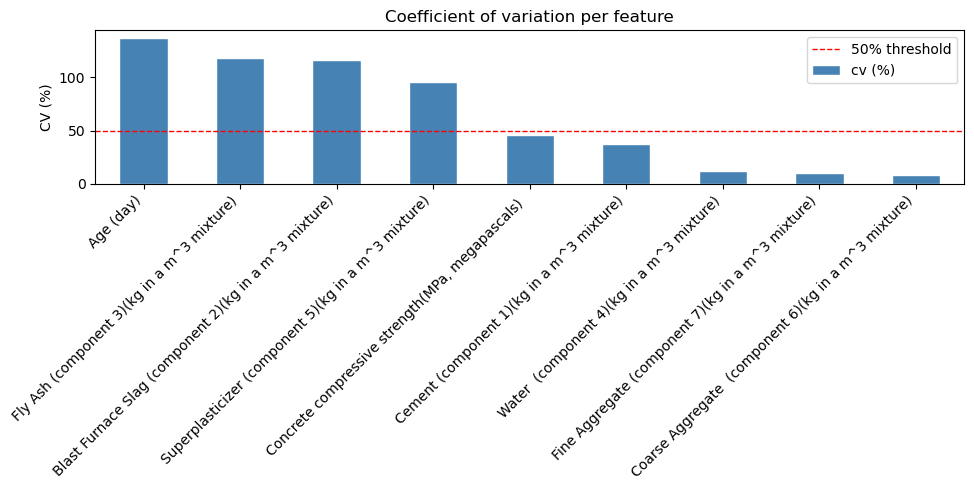

In [4]:
#features with high variation

fig, ax = plt.subplots(figsize=(10, 5))
cv_df['cv (%)'].plot(kind='bar', ax=ax, color='steelblue', edgecolor='white')
ax.axhline(50, color='red', linestyle='--', linewidth=1, label='50% threshold')
ax.set_title('Coefficient of variation per feature')
ax.set_ylabel('CV (%)')
ax.set_xlabel('')
ax.legend()
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

### 5. Boxplots showing distribution shape, spread, and outliers together.

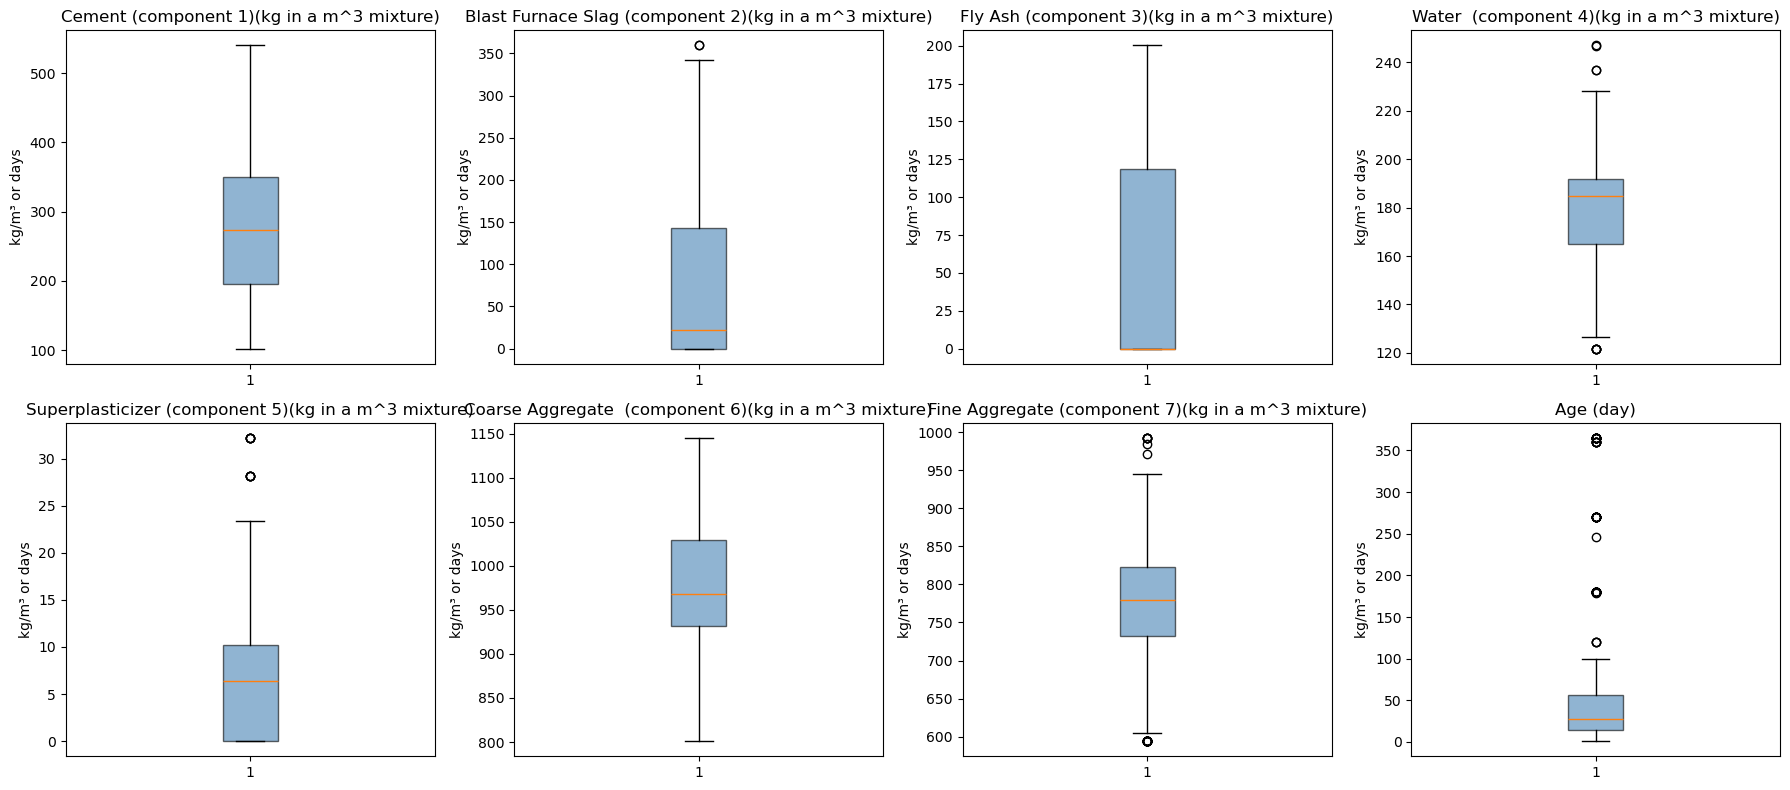

In [5]:
# boxplots show distribution shape, spread, and outliers together
fig, axes = plt.subplots(2, 4, figsize=(18, 8))
axes = axes.flatten()

for i, col in enumerate(df.columns[:-1]):  # exclude strength
    axes[i].boxplot(df[col].dropna(), patch_artist=True,
                    boxprops=dict(facecolor='steelblue', alpha=0.6))
    axes[i].set_title(col)
    axes[i].set_ylabel('kg/m³ or days')

plt.tight_layout()
plt.show()

### 6. Summary

Depiction of mean, median, std deviation, minimum, maximum , Coefficient of Variation, Skewness and Outliers 

In [6]:
summary = pd.DataFrame({
    'mean':   df.mean().round(2),
    'median': df.median().round(2),
    'std':    df.std().round(2),
    'min':    df.min().round(2),
    'max':    df.max().round(2),
    'cv (%)': cv,
    'skewness': df.skew().round(2),
    'outliers': [(df[c] > df[c].quantile(0.75) + 1.5*df[c].std()).sum() 
                  for c in df.columns]
})
print(summary)

                                                      mean  median     std  \
Cement (component 1)(kg in a m^3 mixture)           281.49  274.00  104.16   
Blast Furnace Slag (component 2)(kg in a m^3 mi...   73.79   22.00   86.11   
Fly Ash (component 3)(kg in a m^3 mixture)           54.15    0.00   63.79   
Water  (component 4)(kg in a m^3 mixture)           181.45  185.00   21.32   
Superplasticizer (component 5)(kg in a m^3 mixt...    6.23    6.35    5.94   
Coarse Aggregate  (component 6)(kg in a m^3 mix...  973.08  968.00   77.45   
Fine Aggregate (component 7)(kg in a m^3 mixture)   773.39  779.32   79.86   
Age (day)                                            45.39   28.00   62.35   
Concrete compressive strength(MPa, megapascals)      35.91   34.35   16.54   

                                                       min     max  cv (%)  \
Cement (component 1)(kg in a m^3 mixture)           102.00   540.0    37.0   
Blast Furnace Slag (component 2)(kg in a m^3 mi...    0.00   35

## 7. Imputation

Imputation of data with:
- Dropping of NaN values
- Mean Imputation
- KNN Imputation

In [7]:

df_clean = df.dropna()

#SIMPLE IMPUTE
imp = SimpleImputer(strategy='mean')
df_mean_imputed = pd.DataFrame(imp.fit_transform(df), columns=df.columns)


#KNN_IMPUTER
imputer_2 = KNNImputer(n_neighbors=5,weights="uniform")
df_knn_imputed = pd.DataFrame(imputer_2.fit_transform(df), columns=df.columns)




In [8]:
print("=== DROPPED ===")
print(df_clean.describe().round(2))

print("\n=== MEAN IMPUTED ===")
print(df_mean_imputed.describe().round(2))

print("\n=== KNN IMPUTED ===")
print(df_knn_imputed.describe().round(2))

=== DROPPED ===
       Cement (component 1)(kg in a m^3 mixture)  \
count                                    1030.00   
mean                                      281.17   
std                                       104.51   
min                                       102.00   
25%                                       192.38   
50%                                       272.90   
75%                                       350.00   
max                                       540.00   

       Blast Furnace Slag (component 2)(kg in a m^3 mixture)  \
count                                            1030.00       
mean                                               73.90       
std                                                86.28       
min                                                 0.00       
25%                                                 0.00       
50%                                                22.00       
75%                                               142.95       
max

### 8. Visualisation

- Comparison of various Imputation Techniques
- All features vs Compressive Strength trends
- Feature Correlation Matrix

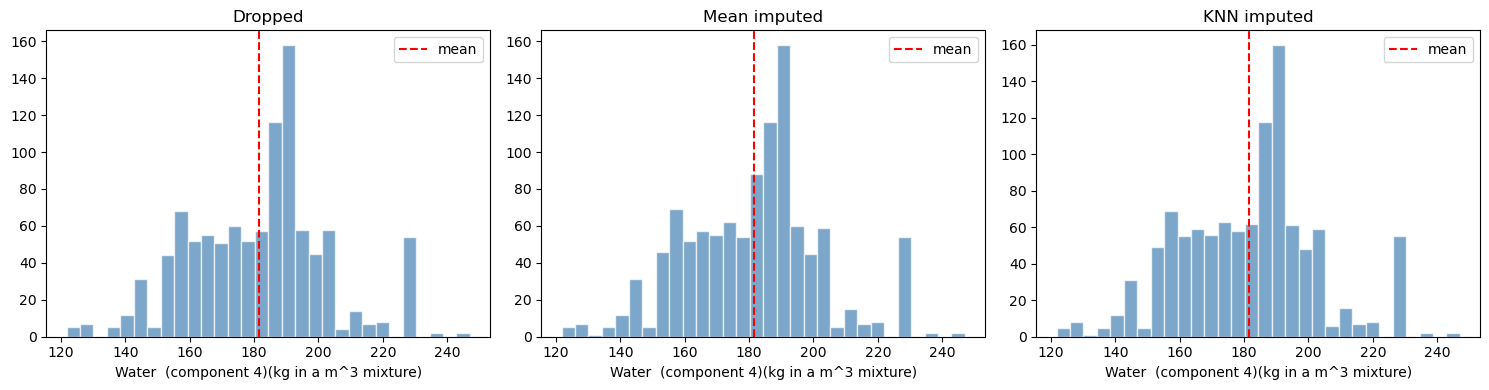

In [9]:
feature = 'Water  (component 4)(kg in a m^3 mixture)'  

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
titles = ['Dropped', 'Mean imputed', 'KNN imputed']
dfs = [df_clean, df_mean_imputed, df_knn_imputed]

for ax, title, d in zip(axes, titles, dfs):
    ax.hist(d[feature], bins=30, color='steelblue', alpha=0.7, edgecolor='white')
    ax.axvline(d[feature].mean(), color='red', linestyle='--', linewidth=1.5, label='mean')
    ax.set_title(title)
    ax.set_xlabel(feature)
    ax.legend()

plt.tight_layout()
plt.show()

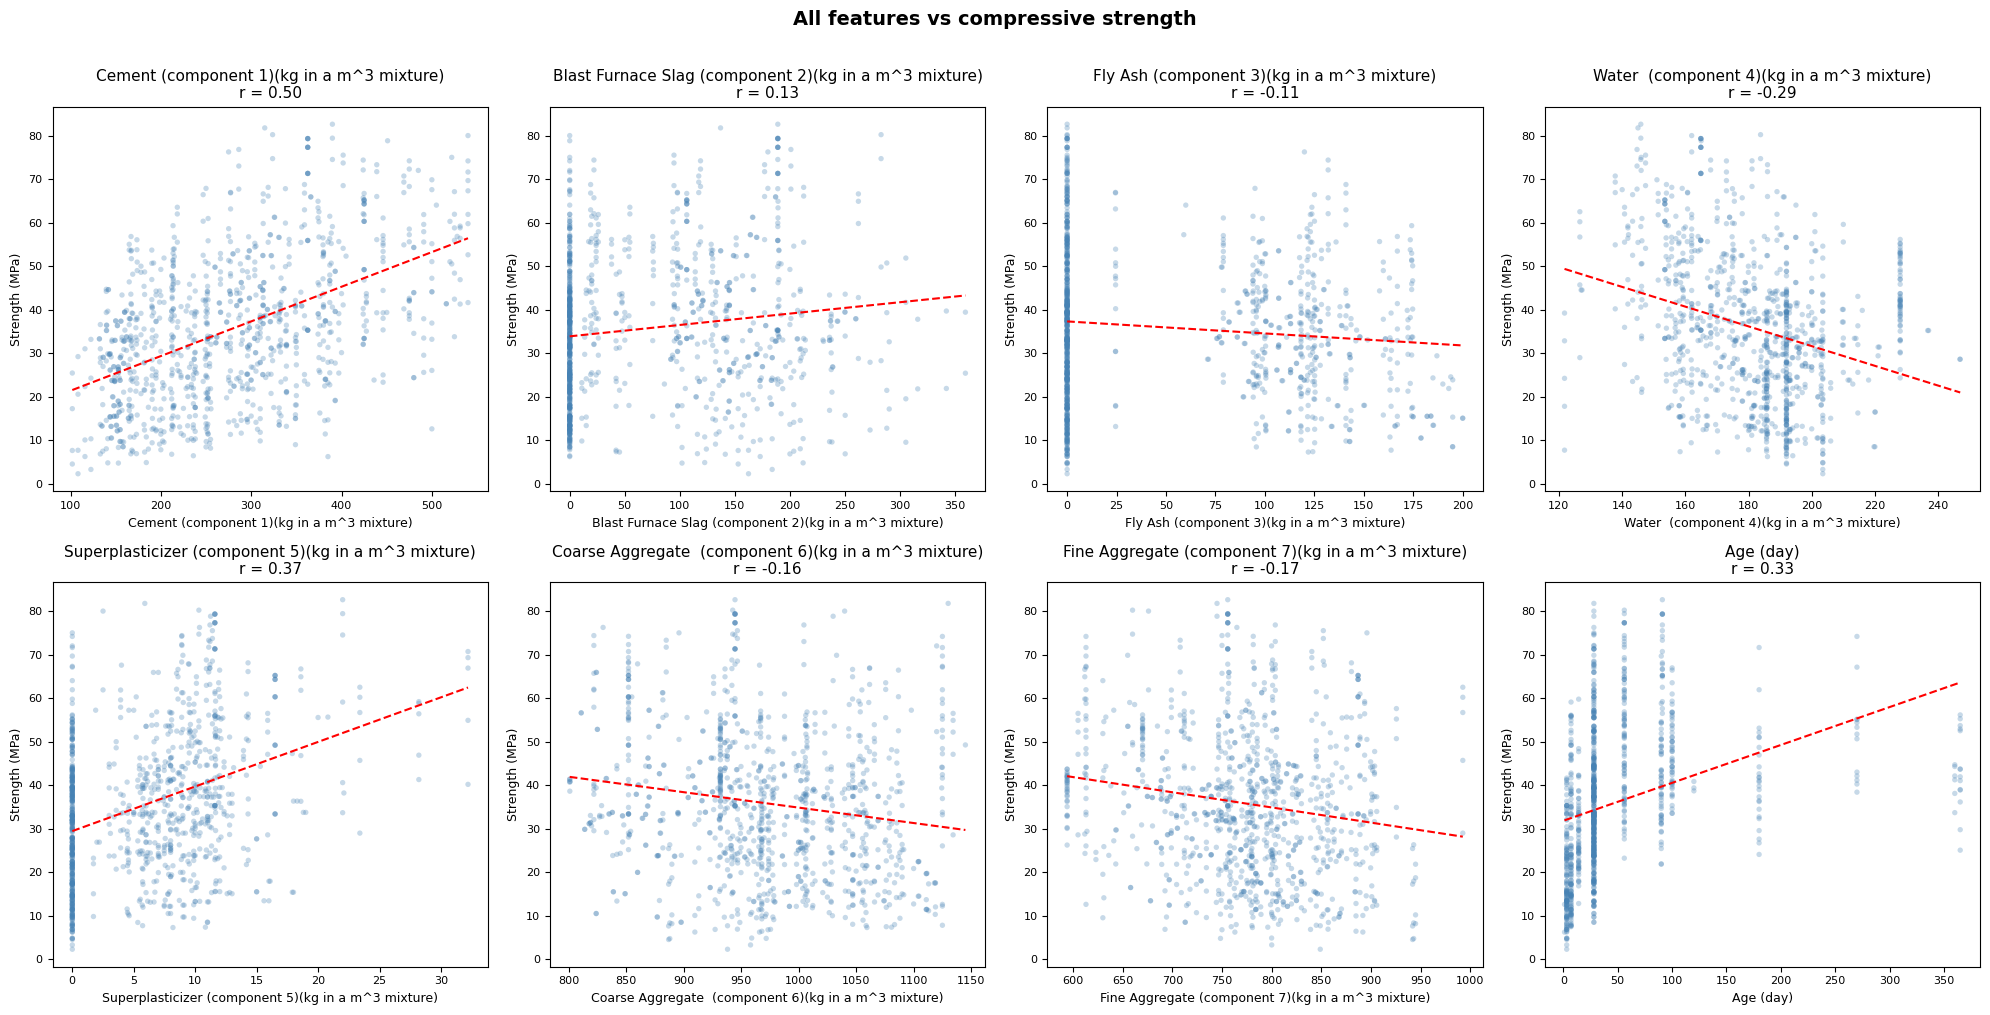

In [10]:


features = [c for c in df_clean.columns if c != 'Concrete compressive strength(MPa, megapascals) ']

fig, axes = plt.subplots(2, 4, figsize=(20, 10))
axes = axes.flatten()

for i, feature in enumerate(features):
    axes[i].scatter(
        df_clean[feature], 
        df_clean['Concrete compressive strength(MPa, megapascals) '],
        alpha=0.3, 
        s=15, 
        color='steelblue',
        edgecolors='none'
    )
    
    #  trend line 
    z = np.polyfit(df_clean[feature], df_clean['Concrete compressive strength(MPa, megapascals) '], 1)
    p = np.poly1d(z)
    x_sorted = np.sort(df_clean[feature])
    axes[i].plot(x_sorted, p(x_sorted), 
                 color='red', linewidth=1.5, linestyle='--', label='trend')
    
    #  correlation 
    r = df_clean[feature].corr(df_clean['Concrete compressive strength(MPa, megapascals) '])
    axes[i].set_title(f"{feature}\nr = {r:.2f}", fontsize=11)
    axes[i].set_xlabel(feature, fontsize=9)
    axes[i].set_ylabel('Strength (MPa)', fontsize=9)
    axes[i].tick_params(labelsize=8)

plt.suptitle('All features vs compressive strength', 
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

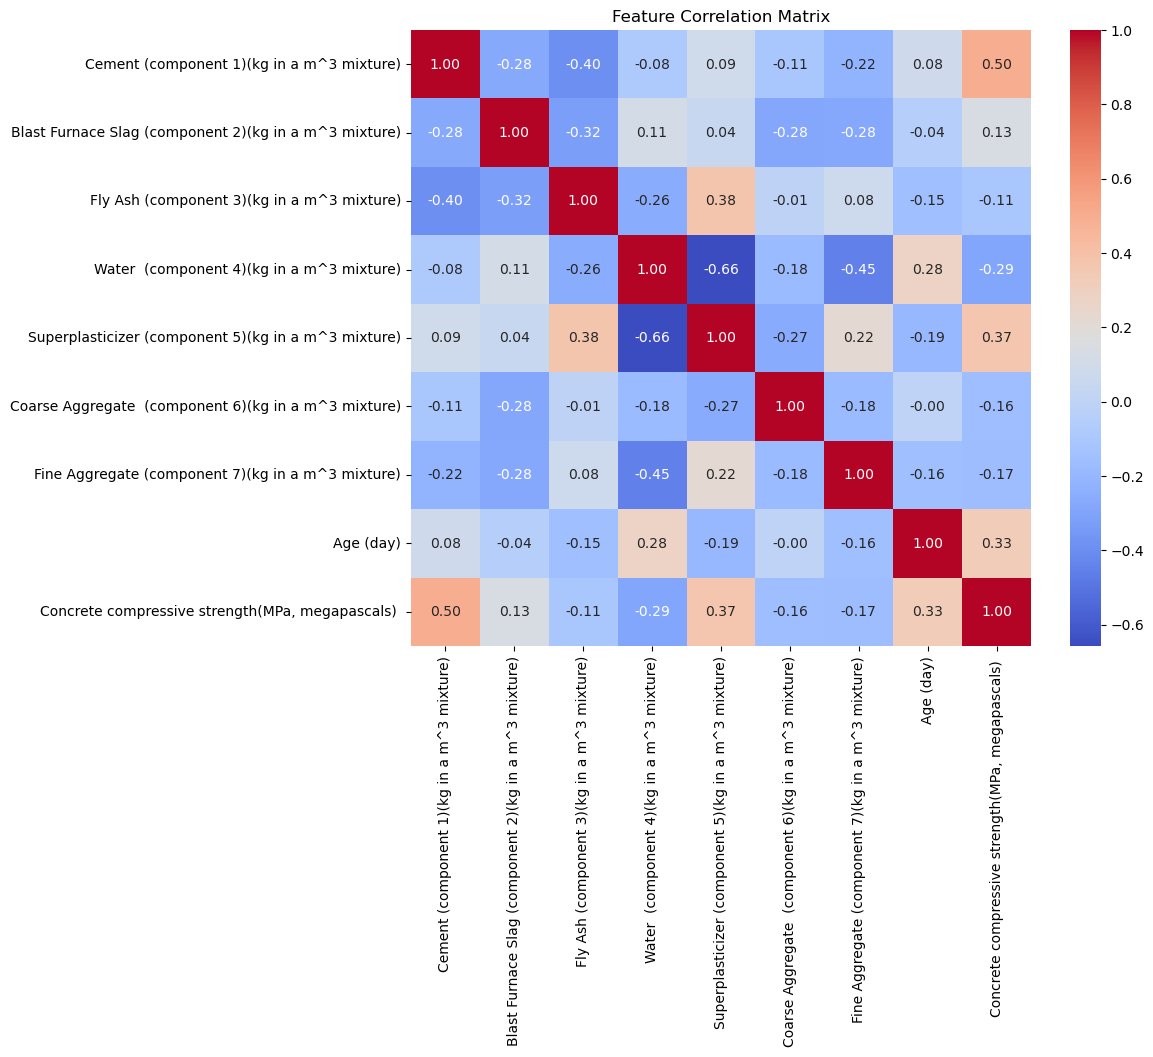

In [ ]:
plot_correlation_matrix(df_clean)

In [16]:
from sklearn.feature_selection import mutual_info_regression
df = df.dropna()
df = df.drop_duplicates()
X = df.drop(columns=["Concrete compressive strength(MPa, megapascals) "])


y = df["Concrete compressive strength(MPa, megapascals) "]

mi_scores = mutual_info_regression(X,y)
print(mi_scores)


[0.23034753 0.10781106 0.10966833 0.27033721 0.14507466 0.18220687
 0.13740303 0.31682894]
